# Final Association Table

This notebook combines association results from GWAS Catalog, HERMES, CARDIoGRAMplusC4D, and FinnGen into one harmonized table for all queried gene regions.

In [21]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [22]:
gwas_path = Path("../data/interim/gwas_catalog/associations.csv")
hermes_path = Path("../data/interim/hermes/associations.csv")
gene_list_path = Path("../data/raw/gene_list/macrophage_gene_symbols.csv")

cardio_cad_path = Path("../data/interim/cardiogram_c4d/cad_associations.csv")
cardio_mi_path = Path("../data/interim/cardiogram_c4d/mi_associations.csv")

finngen_hf_path = Path("../data/interim/finngen/hf_associations.csv")
finngen_cad_path = Path("../data/interim/finngen/cad_associations.csv")
finngen_mi_path = Path("../data/interim/finngen/mi_associations.csv")

out_dir = Path("../data/final/")
out_dir.mkdir(parents=True, exist_ok=True)

figures_dir = Path("../data/final/figures")
figures_dir.mkdir(parents=True, exist_ok=True)

out_csv = out_dir / "association_results.csv"

In [23]:
input_paths = [
    gwas_path,
    hermes_path,
    cardio_cad_path,
    cardio_mi_path,
    finngen_hf_path,
    finngen_cad_path,
    finngen_mi_path,
]

missing_paths = [path for path in input_paths if not path.exists()]

if missing_paths:
    raise FileNotFoundError(f"Missing input files: {missing_paths}")

In [24]:
final_columns = [
    "source_dataset",
    "query_source",
    "trait_name",
    "trait_id",
    "accession_id",
    "pubmed_id",
    "first_author",
    "official_gene_symbol",
    "region_assembly",
    "chromosome",
    "gene_start",
    "gene_end",
    "region_start",
    "region_end",
    "strand",
    "strand_symbol",
    "rsID",
    "variant_id",
    "position",
    "location_relative_to_gene",
    "distance_from_gene",
    "effect_allele",
    "other_allele",
    "effect_size",
    "standard_error",
    "odds_ratio",
    "ci_lower",
    "ci_upper",
    "p_value",
    "allele_frequency",
    "allele_frequency_cases",
    "allele_frequency_controls",
    "mapped_genes",
    "nearest_genes",
    "association_id",
]

In [25]:
def get_column(df, column_name):
    if column_name in df.columns:
        return df[column_name]

    return pd.Series(pd.NA, index=df.index)


def ensure_final_columns(df):
    df = df.copy()

    for col in final_columns:
        if col not in df.columns:
            df[col] = pd.NA

    return df[final_columns]

In [26]:
gwas_df = pd.read_csv(gwas_path, sep=";")

gwas_final = pd.DataFrame({
    "source_dataset": "GWAS Catalog",
    "trait_name": get_column(gwas_df, "trait_name"),
    "official_gene_symbol": get_column(gwas_df, "query_value"),
    "query_source": get_column(gwas_df, "query_source"),
    "region_assembly": pd.NA,
    "gene_start": pd.NA,
    "gene_end": pd.NA,
    "region_start": pd.NA,
    "region_end": pd.NA,
    "strand": pd.NA,
    "strand_symbol": pd.NA,
    "location_relative_to_gene": pd.NA,
    "distance_from_gene": pd.NA,
    "association_id": get_column(gwas_df, "association_id"),
    "variant_id": pd.NA,
    "rsID": get_column(gwas_df, "rsID"),
    "chromosome": pd.NA,
    "position": pd.NA,
    "effect_allele": get_column(gwas_df, "risk_allele"),
    "other_allele": pd.NA,
    "effect_size": pd.NA,
    "standard_error": pd.NA,
    "odds_ratio": pd.NA,
    "ci_lower": pd.NA,
    "ci_upper": pd.NA,
    "p_value": get_column(gwas_df, "p_value"),
    "allele_frequency": get_column(gwas_df, "risk_frequency"),
    "allele_frequency_cases": pd.NA,
    "allele_frequency_controls": pd.NA,
    "mapped_genes": get_column(gwas_df, "mapped_genes"),
    "nearest_genes": pd.NA,
    "trait_id": get_column(gwas_df, "trait_id"),
    "accession_id": get_column(gwas_df, "accession_id"),
    "pubmed_id": get_column(gwas_df, "pubmed_id"),
    "first_author": get_column(gwas_df, "first_author"),
})

gwas_final = ensure_final_columns(gwas_final)

gwas_final.head()

,source_dataset,query_source,trait_name,trait_id,accession_id,pubmed_id,first_author,official_gene_symbol,region_assembly,chromosome,gene_start,gene_end,region_start,region_end,strand,strand_symbol,rsID,variant_id,position,location_relative_to_gene,distance_from_gene,effect_allele,other_allele,effect_size,standard_error,odds_ratio,ci_lower,ci_upper,p_value,allele_frequency,allele_frequency_cases,allele_frequency_controls,mapped_genes,nearest_genes,association_id
0,GWAS Catalog,mapped_gene,low density lipoprotein cholesterol measurement,EFO_0004611,GCST90239655,34887591,Graham SE,APOE,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,rs7412,<NA>,<NA>,<NA>,<NA>,?,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0.0,NR,<NA>,<NA>,APOE,<NA>,101328355
1,GWAS Catalog,mapped_gene,low density lipoprotein cholesterol measurement,EFO_0004611,GCST90239658,34887591,Graham SE,APOE,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,rs7412,<NA>,<NA>,<NA>,<NA>,T,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0.0,0.0750304,<NA>,<NA>,APOE,<NA>,101331036
2,GWAS Catalog,mapped_gene,apolipoprotein B measurement,EFO_0004615,GCST90019496,33462484,Sinnott-Armstrong N,APOE,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,rs7412,<NA>,<NA>,<NA>,<NA>,T,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0.0,NR,<NA>,<NA>,APOE,<NA>,87309502
3,GWAS Catalog,mapped_gene,non-high density lipoprotein cholesterol measu...,EFO_0005689,GCST90239667,34887591,Graham SE,APOE,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,rs7412,<NA>,<NA>,<NA>,<NA>,?,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0.0,NR,<NA>,<NA>,APOE,<NA>,101338523
4,GWAS Catalog,mapped_gene,total cholesterol measurement,EFO_0004574,GCST90239673,34887591,Graham SE,APOE,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,rs7412,<NA>,<NA>,<NA>,<NA>,?,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0.0,NR,<NA>,<NA>,APOE,<NA>,101343626


In [27]:
hermes_df = pd.read_csv(hermes_path, sep=";")

hermes_final = pd.DataFrame({
    "source_dataset": "HERMES",
    "trait_name": "Heart failure",
    "official_gene_symbol": get_column(hermes_df, "query_value"),
    "query_source": get_column(hermes_df, "query_source"),
    "region_assembly": get_column(hermes_df, "region_assembly"),
    "gene_start": get_column(hermes_df, "gene_start"),
    "gene_end": get_column(hermes_df, "gene_end"),
    "region_start": get_column(hermes_df, "region_start"),
    "region_end": get_column(hermes_df, "region_end"),
    "strand": get_column(hermes_df, "strand"),
    "strand_symbol": get_column(hermes_df, "strand_symbol"),
    "location_relative_to_gene": get_column(hermes_df, "location_relative_to_gene"),
    "distance_from_gene": get_column(hermes_df, "distance_from_gene"),
    "association_id": pd.NA,
    "variant_id": get_column(hermes_df, "HERMES_marker_name"),
    "rsID": get_column(hermes_df, "rsID"),
    "chromosome": get_column(hermes_df, "HERMES_CHR"),
    "position": get_column(hermes_df, "HERMES_BP"),
    "effect_allele": get_column(hermes_df, "HERMES_Allele1"),
    "other_allele": get_column(hermes_df, "HERMES_Allele2"),
    "effect_size": get_column(hermes_df, "HERMES_effect"),
    "standard_error": get_column(hermes_df, "HERMES_std_error"),
    "odds_ratio": pd.NA,
    "ci_lower": pd.NA,
    "ci_upper": pd.NA,
    "p_value": get_column(hermes_df, "HERMES_p_value"),
    "allele_frequency": get_column(hermes_df, "HERMES_Allele1_freq"),
    "allele_frequency_cases": pd.NA,
    "allele_frequency_controls": pd.NA,
    "mapped_genes": pd.NA,
    "nearest_genes": pd.NA,
    "trait_id": pd.NA,
    "accession_id": pd.NA,
    "pubmed_id": pd.NA,
    "first_author": pd.NA,
})

hermes_final = ensure_final_columns(hermes_final)

hermes_final.head()

,source_dataset,query_source,trait_name,trait_id,accession_id,pubmed_id,first_author,official_gene_symbol,region_assembly,chromosome,gene_start,gene_end,region_start,region_end,strand,strand_symbol,rsID,variant_id,position,location_relative_to_gene,distance_from_gene,effect_allele,other_allele,effect_size,standard_error,odds_ratio,ci_lower,ci_upper,p_value,allele_frequency,allele_frequency_cases,allele_frequency_controls,mapped_genes,nearest_genes,association_id
0,HERMES,gene_region,Heart failure,<NA>,<NA>,<NA>,<NA>,APOE,GRCh37,19,45409011,45412650,45359011,45462650,1,+,rs5117,19:45418790,45418790,downstream,6140,t,c,0.0405,0.0113,<NA>,<NA>,<NA>,0.000318,0.7741,<NA>,<NA>,<NA>,<NA>,<NA>
1,HERMES,gene_region,Heart failure,<NA>,<NA>,<NA>,<NA>,APOE,GRCh37,19,45409011,45412650,45359011,45462650,1,+,rs438811,19:45416741,45416741,downstream,4091,t,c,-0.0377,0.0108,<NA>,<NA>,<NA>,0.000459,0.2306,<NA>,<NA>,<NA>,<NA>,<NA>
2,HERMES,gene_region,Heart failure,<NA>,<NA>,<NA>,<NA>,APOE,GRCh37,19,45409011,45412650,45359011,45462650,1,+,rs10414043,19:45415713,45415713,downstream,3063,a,g,-0.0471,0.0140,<NA>,<NA>,<NA>,0.000748,0.1332,<NA>,<NA>,<NA>,<NA>,<NA>
3,HERMES,gene_region,Heart failure,<NA>,<NA>,<NA>,<NA>,APOE,GRCh37,19,45409011,45412650,45359011,45462650,1,+,rs429358,19:45411941,45411941,intragenic,0,t,c,0.0414,0.0126,<NA>,<NA>,<NA>,0.001003,0.8426,<NA>,<NA>,<NA>,<NA>,<NA>
4,HERMES,gene_region,Heart failure,<NA>,<NA>,<NA>,<NA>,APOE,GRCh37,19,45409011,45412650,45359011,45462650,1,+,rs7256200,19:45415935,45415935,downstream,3285,t,g,-0.0442,0.0141,<NA>,<NA>,<NA>,0.001709,0.1330,<NA>,<NA>,<NA>,<NA>,<NA>


In [28]:
def build_cardiogram_final(path, trait_label, prefix):
    df = pd.read_csv(path, sep=";")

    final_df = pd.DataFrame({
        "source_dataset": "CARDIoGRAMplusC4D",
        "trait_name": trait_label,
        "official_gene_symbol": get_column(df, "query_value"),
        "query_source": get_column(df, "query_source"),
        "region_assembly": get_column(df, "region_assembly"),
        "gene_start": get_column(df, "gene_start"),
        "gene_end": get_column(df, "gene_end"),
        "region_start": get_column(df, "region_start"),
        "region_end": get_column(df, "region_end"),
        "strand": get_column(df, "strand"),
        "strand_symbol": get_column(df, "strand_symbol"),
        "location_relative_to_gene": get_column(df, "location_relative_to_gene"),
        "distance_from_gene": get_column(df, "distance_from_gene"),
        "association_id": pd.NA,
        "variant_id": get_column(df, f"{prefix}_hm_variant_id"),
        "rsID": get_column(df, f"{prefix}_hm_rsid"),
        "chromosome": get_column(df, f"{prefix}_hm_chrom"),
        "position": get_column(df, f"{prefix}_hm_pos"),
        "effect_allele": get_column(df, f"{prefix}_hm_effect_allele"),
        "other_allele": get_column(df, f"{prefix}_hm_other_allele"),
        "effect_size": get_column(df, f"{prefix}_hm_beta"),
        "standard_error": get_column(df, f"{prefix}_standard_error"),
        "odds_ratio": get_column(df, f"{prefix}_hm_odds_ratio"),
        "ci_lower": get_column(df, f"{prefix}_hm_ci_lower"),
        "ci_upper": get_column(df, f"{prefix}_hm_ci_upper"),
        "p_value": get_column(df, f"{prefix}_p_value"),
        "allele_frequency": get_column(df, f"{prefix}_hm_effect_allele_frequency"),
        "allele_frequency_cases": pd.NA,
        "allele_frequency_controls": pd.NA,
        "mapped_genes": pd.NA,
        "nearest_genes": pd.NA,
        "trait_id": pd.NA,
        "accession_id": pd.NA,
        "pubmed_id": pd.NA,
        "first_author": pd.NA,
    })

    return ensure_final_columns(final_df)

In [29]:
cardio_cad_final = build_cardiogram_final(
    path=cardio_cad_path,
    trait_label="Coronary artery disease",
    prefix="CAD"
)

cardio_mi_final = build_cardiogram_final(
    path=cardio_mi_path,
    trait_label="Myocardial infarction",
    prefix="MI"
)

cardio_cad_final.shape, cardio_mi_final.shape

((22326, 35), (21083, 35))

In [30]:
def build_finngen_final(path, trait_label):
    df = pd.read_csv(path, sep=";")

    variant_id = (
        get_column(df, "FINNGEN_CHR").astype("string")
        + ":"
        + get_column(df, "FINNGEN_BP").astype("string")
        + ":"
        + get_column(df, "FINNGEN_ref").astype("string")
        + ":"
        + get_column(df, "FINNGEN_alt").astype("string")
    )

    final_df = pd.DataFrame({
        "source_dataset": "FinnGen",
        "trait_name": trait_label,
        "official_gene_symbol": get_column(df, "query_value"),
        "query_source": get_column(df, "query_source"),
        "region_assembly": get_column(df, "region_assembly"),
        "gene_start": get_column(df, "gene_start"),
        "gene_end": get_column(df, "gene_end"),
        "region_start": get_column(df, "region_start"),
        "region_end": get_column(df, "region_end"),
        "strand": get_column(df, "strand"),
        "strand_symbol": get_column(df, "strand_symbol"),
        "location_relative_to_gene": get_column(df, "location_relative_to_gene"),
        "distance_from_gene": get_column(df, "distance_from_gene"),
        "association_id": pd.NA,
        "variant_id": variant_id,
        "rsID": get_column(df, "FINNGEN_rsids"),
        "chromosome": get_column(df, "FINNGEN_CHR"),
        "position": get_column(df, "FINNGEN_BP"),
        "effect_allele": get_column(df, "FINNGEN_alt"),
        "other_allele": get_column(df, "FINNGEN_ref"),
        "effect_size": get_column(df, "FINNGEN_beta"),
        "standard_error": get_column(df, "FINNGEN_std_error"),
        "odds_ratio": pd.NA,
        "ci_lower": pd.NA,
        "ci_upper": pd.NA,
        "p_value": get_column(df, "FINNGEN_p_value"),
        "allele_frequency": get_column(df, "FINNGEN_alt_allele_freq"),
        "allele_frequency_cases": get_column(df, "FINNGEN_alt_allele_freq_cases"),
        "allele_frequency_controls": get_column(df, "FINNGEN_alt_allele_freq_controls"),
        "mapped_genes": pd.NA,
        "nearest_genes": get_column(df, "FINNGEN_nearest_genes"),
        "trait_id": pd.NA,
        "accession_id": pd.NA,
        "pubmed_id": pd.NA,
        "first_author": pd.NA,
    })

    return ensure_final_columns(final_df)

In [31]:
finngen_hf_final = build_finngen_final(
    path=finngen_hf_path,
    trait_label="Heart failure"
)

finngen_cad_final = build_finngen_final(
    path=finngen_cad_path,
    trait_label="Coronary artery disease"
)

finngen_mi_final = build_finngen_final(
    path=finngen_mi_path,
    trait_label="Myocardial infarction"
)

finngen_hf_final.shape, finngen_cad_final.shape, finngen_mi_final.shape

((53855, 35), (53855, 35), (53853, 35))

In [32]:
dfs = [
    gwas_final,
    hermes_final,
    cardio_cad_final,
    cardio_mi_final,
    finngen_hf_final,
    finngen_cad_final,
    finngen_mi_final,
]

dfs = [
    df.dropna(axis=1, how="all")
    for df in dfs
    if df is not None and not df.empty
]

final_df = pd.concat(dfs, ignore_index=True)

final_df = ensure_final_columns(final_df)

numeric_cols = [
    "gene_start",
    "gene_end",
    "region_start",
    "region_end",
    "distance_from_gene",
    "position",
    "effect_size",
    "standard_error",
    "odds_ratio",
    "ci_lower",
    "ci_upper",
    "p_value",
    "allele_frequency",
    "allele_frequency_cases",
    "allele_frequency_controls",
]

for col in numeric_cols:
    final_df[col] = pd.to_numeric(final_df[col], errors="coerce")

calculated_or = np.exp(final_df["effect_size"])

final_df["odds_ratio"] = final_df["odds_ratio"].fillna(calculated_or)

final_df = final_df.sort_values(
    ["official_gene_symbol", "p_value", "source_dataset", "trait_name"],
    ascending=[True, True, True, True],
    na_position="last"
).reset_index(drop=True)

rows_before_deduplication = len(final_df)

final_df = final_df.drop_duplicates().reset_index(drop=True)

rows_after_deduplication = len(final_df)
duplicate_rows_removed = rows_before_deduplication - rows_after_deduplication

final_df.shape

(238651, 35)

In [33]:
final_df.to_csv(out_csv, index=False, sep=";")

In [34]:
summary = {
    "total_rows": int(len(final_df)),
    "unique_rsIDs": int(final_df["rsID"].dropna().nunique()),
    "duplicate_rows_removed": int(duplicate_rows_removed),
    "source_datasets": final_df["source_dataset"].dropna().astype(str).unique().tolist(),
    "rows_by_source_dataset": {
        str(source): int(count)
        for source, count in final_df
        .groupby("source_dataset")
        .size()
        .to_dict()
        .items()
    },
}

summary

{'total_rows': 238651,
 'unique_rsIDs': 51502,
 'duplicate_rows_removed': 0,
 'source_datasets': ['GWAS Catalog', 'FinnGen', 'CARDIoGRAMplusC4D', 'HERMES'],
 'rows_by_source_dataset': {'CARDIoGRAMplusC4D': 43409,
  'FinnGen': 161563,
  'GWAS Catalog': 12427,
  'HERMES': 21252}}

## Results

In [35]:
all_genes = pd.read_csv(gene_list_path)["gene_symbol"].dropna().tolist()

genes_with_associations = set(final_df["official_gene_symbol"].dropna().unique())
genes_without_associations = sorted(set(all_genes) - genes_with_associations)

print(f"Total genes in analysis:       {len(all_genes)}")
print(f"Genes with associations:       {len(genes_with_associations)}")
print(f"Genes without associations:    {len(genes_without_associations)}")
print(f"Genes with zero association rows: {genes_without_associations}")

Total genes in analysis:       52
Genes with associations:       51
Genes without associations:    1
Genes with zero association rows: ['TIMP1']


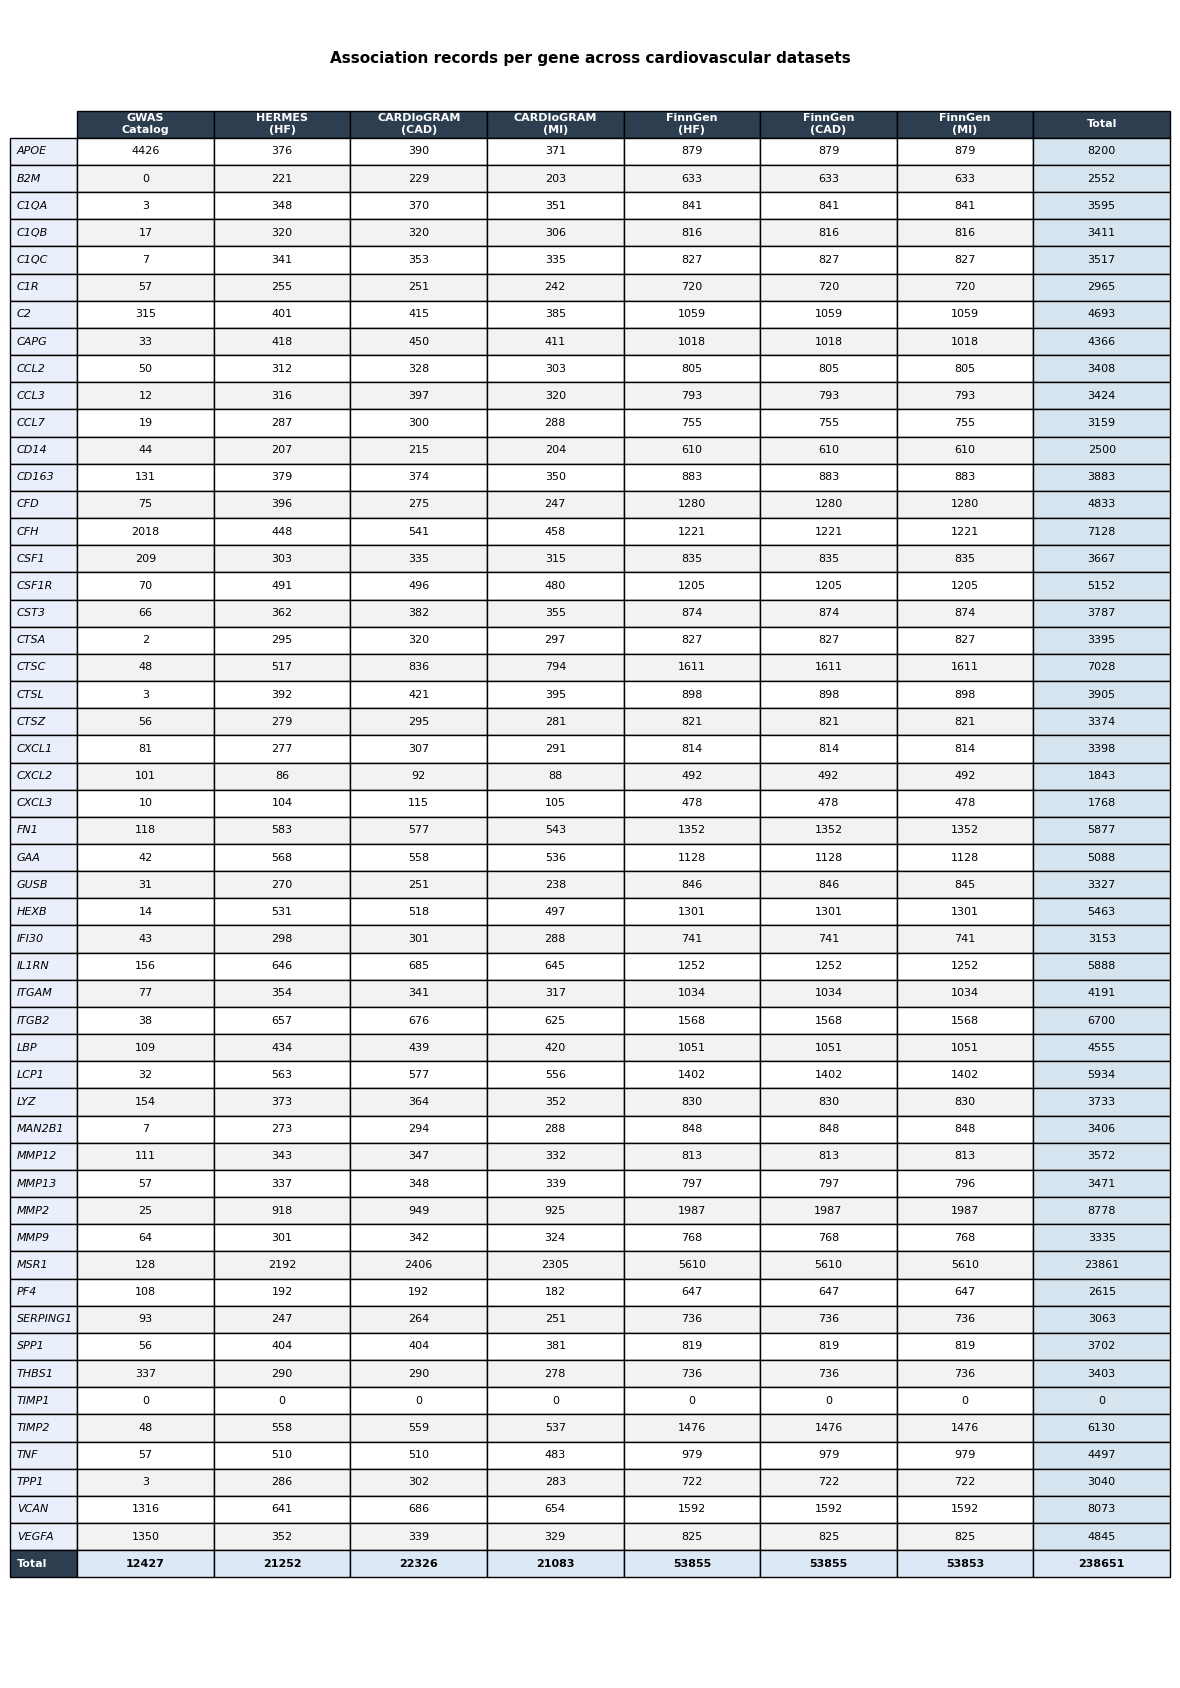

Table saved to: ../data/final/figures/gene_associations_table.png


In [36]:
source_phenotype_order = [
    ("GWAS Catalog",       ""),
    ("HERMES",             "Heart failure"),
    ("CARDIoGRAMplusC4D",  "Coronary artery disease"),
    ("CARDIoGRAMplusC4D",  "Myocardial infarction"),
    ("FinnGen",            "Heart failure"),
    ("FinnGen",            "Coronary artery disease"),
    ("FinnGen",            "Myocardial infarction"),
]

column_labels = [
    "GWAS Catalog",
    "HERMES\n(HF)",
    "CARDIoGRAMplusC4D\n(CAD)",
    "CARDIoGRAMplusC4D\n(MI)",
    "FinnGen\n(HF)",
    "FinnGen\n(CAD)",
    "FinnGen\n(MI)",
    "Total",
]

summary_rows = []

for gene in sorted(all_genes):
    gene_df = final_df[final_df["official_gene_symbol"] == gene]
    row = {"Gene": gene}

    for (source, trait), label in zip(source_phenotype_order, column_labels[:-1]):
        if source == "GWAS Catalog":
            count = int((gene_df["source_dataset"] == source).sum())
        else:
            count = int(
                ((gene_df["source_dataset"] == source) &
                 (gene_df["trait_name"] == trait)).sum()
            )
        row[label] = count

    row["Total"] = int(gene_df.shape[0])
    summary_rows.append(row)

gene_summary_df = pd.DataFrame(summary_rows).set_index("Gene")

total_row = gene_summary_df.sum(axis=0).rename("Total").to_frame().T
total_row.index.name = "Gene"
gene_summary_df = pd.concat([gene_summary_df, total_row])

# render as matplotlib table and save as PNG
display_labels = [
    "GWAS\nCatalog",
    "HERMES\n(HF)",
    "CARDIoGRAM\n(CAD)",
    "CARDIoGRAM\n(MI)",
    "FinnGen\n(HF)",
    "FinnGen\n(CAD)",
    "FinnGen\n(MI)",
    "Total",
]

n_rows, n_cols = gene_summary_df.shape
fig_w = n_cols * 1.3 + 1.5
fig_h = (n_rows + 1) * 0.32

fig, ax = plt.subplots(figsize=(fig_w, fig_h))
ax.axis("off")

cell_text = gene_summary_df.values.astype(int).tolist()
row_labels = gene_summary_df.index.tolist()

table = ax.table(
    cellText=cell_text,
    rowLabels=row_labels,
    colLabels=display_labels,
    loc="center",
    cellLoc="center",
)

table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.3)

# style header row
for col_idx in range(n_cols):
    cell = table[0, col_idx]
    cell.set_facecolor("#2c3e50")
    cell.set_text_props(color="white", fontweight="bold")

# style row labels (gene names) and alternate row shading
for row_idx in range(1, n_rows + 1):
    gene_name = row_labels[row_idx - 1]

    # Total row at the bottom gets distinct styling
    is_total_row = gene_name == "Total"
    row_bg = "#dce8f5" if is_total_row else ("#f2f2f2" if row_idx % 2 == 0 else "white")

    label_cell = table[row_idx, -1]
    label_cell.set_facecolor("#2c3e50" if is_total_row else "#eaf0fb")
    label_cell.set_text_props(
        fontstyle="italic" if not is_total_row else "normal",
        fontweight="bold" if is_total_row else "normal",
        color="white" if is_total_row else "black",
    )

    for col_idx in range(n_cols):
        cell = table[row_idx, col_idx]
        cell.set_facecolor("#dce8f5" if is_total_row else row_bg)
        if is_total_row:
            cell.set_text_props(fontweight="bold")

        # highlight Total column (last col) slightly
        if col_idx == n_cols - 1 and not is_total_row:
            cell.set_facecolor("#d6e4f0")

    fig.suptitle(
    "Association records per gene across cardiovascular datasets",
    fontsize=11, fontweight="bold", y=0.95
)

plt.tight_layout()

table_out = figures_dir / "gene_associations_table.png"
fig.savefig(table_out, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print(f"Table saved to: {table_out}")

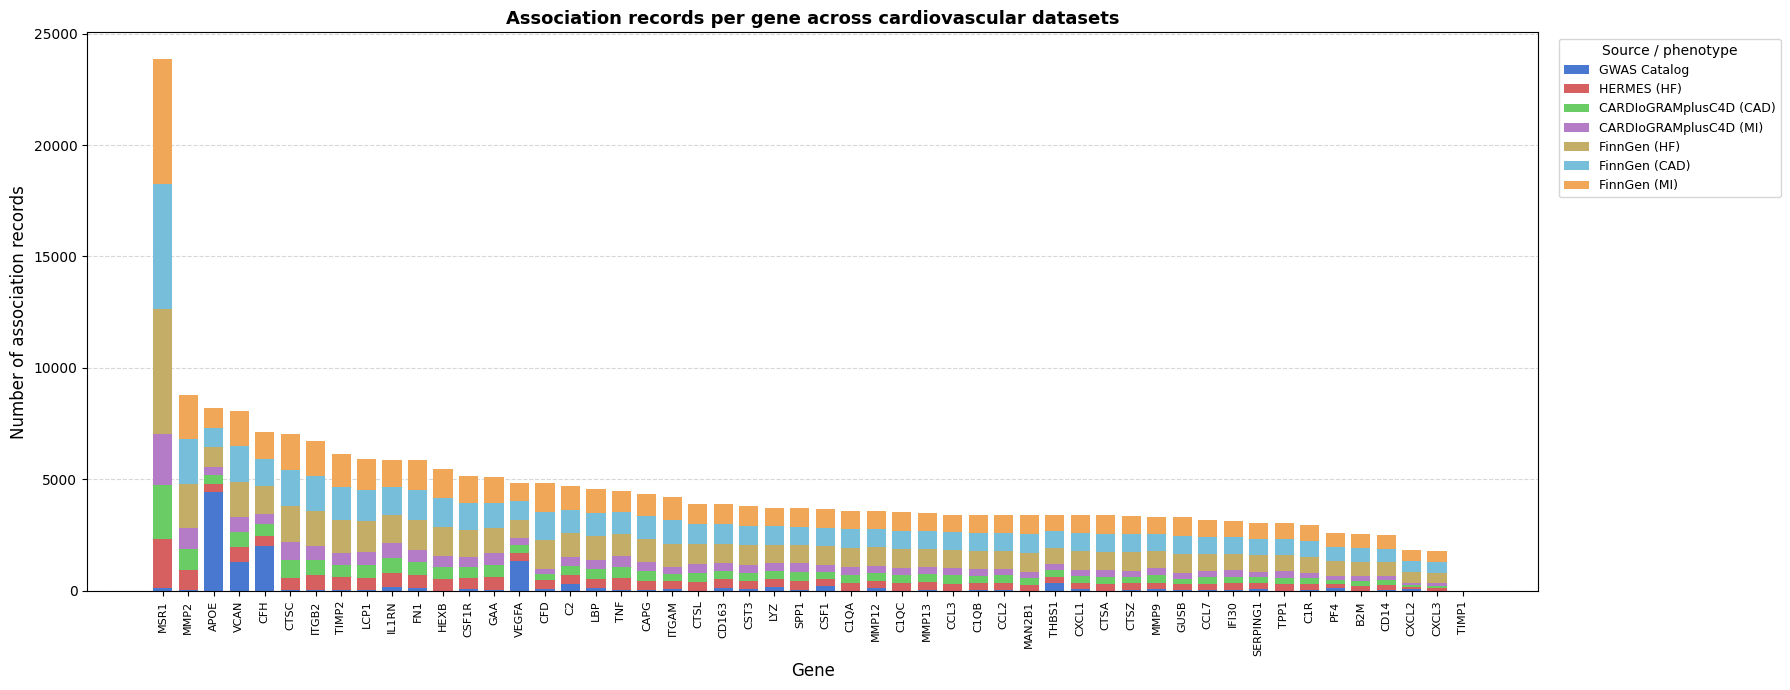

Figure saved to: ../data/final/figures/gene_associations_plot.png


In [37]:
plot_cols = column_labels

colors = [
    "#4878CF",
    "#D65F5F",
    "#6ACC65",
    "#B47CC7",
    "#C4AD66",
    "#77BEDB",
    "#F0A757",
]

legend_labels = [
    "GWAS Catalog",
    "HERMES (HF)",
    "CARDIoGRAMplusC4D (CAD)",
    "CARDIoGRAMplusC4D (MI)",
    "FinnGen (HF)",
    "FinnGen (CAD)",
    "FinnGen (MI)",
]

plot_df = gene_summary_df[plot_cols].copy()
plot_df = plot_df.drop(index="Total", errors="ignore")

row_totals = plot_df.sum(axis=1)
plot_df = plot_df.loc[row_totals.sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(18, 7))

bottom = np.zeros(len(plot_df))
for col, color, legend_label in zip(plot_cols, colors, legend_labels):
    values = plot_df[col].values
    ax.bar(plot_df.index, values, bottom=bottom, color=color, label=legend_label, width=0.75)
    bottom += values

ax.set_xlabel("Gene", fontsize=12)
ax.set_ylabel("Number of association records", fontsize=12)
ax.set_title(
    "Association records per gene across cardiovascular datasets",
    fontsize=13, fontweight="bold"
)
ax.set_xticks(range(len(plot_df)))
ax.set_xticklabels(plot_df.index, rotation=90, fontsize=8)
ax.legend(
    title="Source / phenotype",
    bbox_to_anchor=(1.01, 1),
    loc="upper left",
    fontsize=9,
    title_fontsize=10,
)
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()

fig_out = figures_dir / "gene_associations_plot.png"
fig.savefig(fig_out, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {fig_out}")